# The Efficient Frontier: Markowitz portfolio optimization in Python

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import cvxopt as opt
from cvxopt import blas, solvers
import pandas as pd

np.random.seed(123)

# Turn off progress printing 
solvers.options['show_progress'] = False

In [2]:
df = pd.read_csv(r'c:\Users\ADMIN\Desktop\Kaggle\data\processed\m1_vn46.csv')
df['time'] = pd.to_datetime(df['time']).dt.normalize()

# Chỉ lấy dữ liệu 4 năm gần nhất
max_date = df['time'].max()
cutoff_date = max_date - pd.DateOffset(years=2)
df = df[df['time'] >= cutoff_date]

# Tính trung bình và std (lợi suất) dựa trên giá close
df_close = df.pivot(index='time', columns='ticker', values='close')
df_close = df_close.dropna(axis=1)
returns = df_close.pct_change().dropna()
return_vec = returns.T.values
n_assets = return_vec.shape[0]
print(f'Loaded {return_vec.shape[0]} assets, {return_vec.shape[1]} observations from {cutoff_date.date()} to {max_date.date()}.')
tickers = df_close.columns.tolist()


Loaded 46 assets, 498 observations from 2024-06-18 to 2026-06-18.


Text(0, 0.5, 'returns')

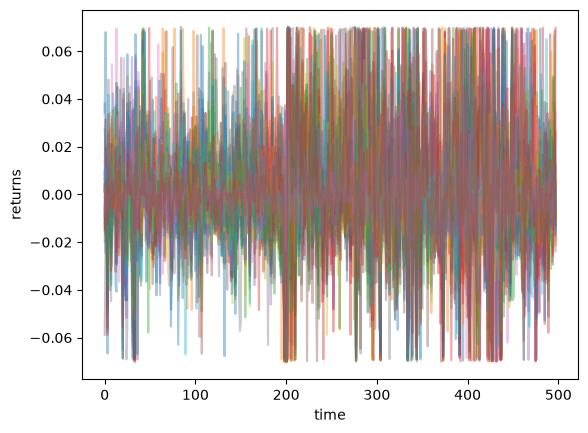

In [3]:
plt.plot(return_vec.T, alpha=.4);
plt.xlabel('time')
plt.ylabel('returns')

In [4]:
def rand_weights(n):
    ''' Produces n random weights that sum to 1 '''
    k = np.random.rand(n)
    return k / sum(k)

print(rand_weights(n_assets))
print (rand_weights(n_assets))

[0.03096531 0.01272187 0.01008591 0.02451168 0.03198789 0.01881149
 0.04360518 0.03044781 0.02138243 0.01743371 0.01525784 0.03241385
 0.0194991  0.0026533  0.01769721 0.03281158 0.00811366 0.00780066
 0.02363299 0.02364527 0.02820573 0.03776609 0.03220958 0.02716636
 0.03212013 0.01435889 0.01608527 0.01014868 0.01305865 0.02805346
 0.00409502 0.01928253 0.01915634 0.02194944 0.01893259 0.01388326
 0.01895575 0.03972045 0.04197774 0.02231187 0.0277412  0.00514044
 0.01410664 0.01844334 0.03851646 0.01113535]
[0.02003185 0.04087202 0.0215435  0.02541727 0.00500258 0.03426907
 0.02500943 0.02260444 0.01421471 0.01261215 0.01729427 0.02825414
 0.03630596 0.02116766 0.02775702 0.0242993  0.02591529 0.02797994
 0.03493267 0.00345017 0.03167059 0.01010506 0.0080546  0.02374029
 0.00396928 0.03671527 0.02601256 0.03000071 0.00066889 0.02465161
 0.02309037 0.00659219 0.00634797 0.02884421 0.01321952 0.02869661
 0.02299076 0.01613012 0.03836605 0.03490479 0.01482159 0.00180778
 0.012639   0.01

In [5]:
def random_portfolio(returns):
    ''' 
    Returns the mean and standard deviation of returns for a random portfolio
    '''

    p = np.asmatrix(np.mean(returns, axis=1))
    w = np.asmatrix(rand_weights(returns.shape[0]))
    C = np.asmatrix(np.cov(returns))
    
    mu = w * p.T
    sigma = np.sqrt(w * C * w.T)
    
    # This recursion reduces outliers to keep plots pretty
    return mu, sigma

In [6]:
n_portfolios = 5000
means, stds = np.column_stack([random_portfolio(return_vec) for _ in range(n_portfolios)])

Text(0.5, 1.0, 'Efficient Frontier')

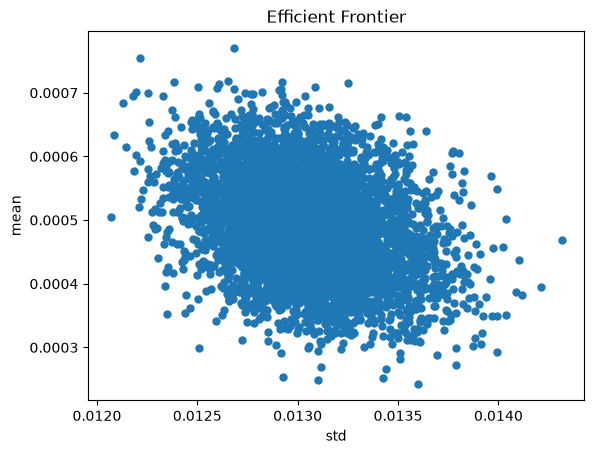

In [7]:
plt.plot(stds, means, 'o', markersize=5)
plt.xlabel('std')
plt.ylabel('mean')
plt.title('Efficient Frontier')

Optimal Weights for Max Sharpe / Frontier Point:
VIC    1.0
dtype: float64


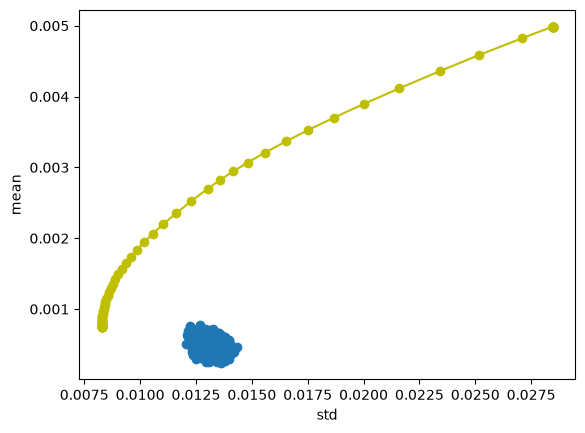

In [8]:
def optimal_portfolio(returns):
    n = len(returns)
    returns = np.asmatrix(returns)
    
    N = 100
    mus = [10**(5.0 * t/N - 1.0) for t in range(N)]
    
    # Convert to cvxopt matrices
    S = opt.matrix(np.cov(returns))
    pbar = opt.matrix(np.mean(returns, axis=1))
    
    # Create constraint matrices
    G = -opt.matrix(np.eye(n))   # negative n x n identity matrix
    h = opt.matrix(0.0, (n ,1))
    A = opt.matrix(1.0, (1, n))
    b = opt.matrix(1.0)
    
    # Calculate efficient frontier weights using quadratic programming
    portfolios = [solvers.qp(mu*S, -pbar, G, h, A, b)['x'] 
                  for mu in mus]
    ## CALCULATE RISKS AND RETURNS FOR FRONTIER
    returns = [blas.dot(pbar, x) for x in portfolios]
    risks = [np.sqrt(blas.dot(x, S*x)) for x in portfolios]
    ## CALCULATE THE 2ND DEGREE POLYNOMIAL OF THE FRONTIER CURVE
    m1 = np.polyfit(returns, risks, 2)
    x1 = np.sqrt(m1[2] / m1[0])
    # CALCULATE THE OPTIMAL PORTFOLIO
    wt = solvers.qp(opt.matrix(x1 * S), -pbar, G, h, A, b)['x']
    return np.asarray(wt), returns, risks

weights, returns, risks = optimal_portfolio(return_vec)

plt.plot(stds, means, 'o')
plt.ylabel('mean')
plt.xlabel('std')
plt.plot(risks, returns, 'y-o')

optimal_w = pd.Series(weights.flatten(), index=tickers)
optimal_w = optimal_w[optimal_w > 0.01].sort_values(ascending=False)
print('Optimal Weights for Max Sharpe / Frontier Point:')
print(optimal_w)
plt.savefig('markowitz_frontier_vn46.png')


In [9]:
optimal_w = pd.Series(weights.flatten(), index=tickers)
optimal_w = optimal_w[optimal_w > 0.01].sort_values(ascending=False)
print('Optimal Weights for Max Sharpe / Frontier Point:')
print(optimal_w)
optimal_w.to_csv('optimal_weights.csv')

Optimal Weights for Max Sharpe / Frontier Point:
VIC    1.0
dtype: float64
